In [4]:
import pandas as pd
import requests

In [5]:
import json

voyage_data = [
    {"voyage_id": 1, "vessel_name": "Oceanic Pioneer", "fuel_consumption_mt": 45.5, "weather_condition": "Clear", "is_typhoon": 0, "route": "Shanghai-Long Beach", "distance_nm": 5700},
    {"voyage_id": 2, "vessel_name": "Oceanic Pioneer", "fuel_consumption_mt": 82.2, "weather_condition": "Typhoon", "is_typhoon": 1, "route": "Shanghai-Long Beach", "distance_nm": 5700},
    {"voyage_id": 3, "vessel_name": "Global Trader", "fuel_consumption_mt": 38.0, "weather_condition": "Heavy Rain", "is_typhoon": 0, "route": "Singapore-Rotterdam", "distance_nm": 8300},
    {"voyage_id": 4, "vessel_name": "Global Trader", "fuel_consumption_mt": 95.5, "weather_condition": "Typhoon", "is_typhoon": 1, "route": "Singapore-Rotterdam", "distance_nm": 8300},
    {"voyage_id": 5, "vessel_name": "Sea Knight", "fuel_consumption_mt": 50.1, "weather_condition": "Clear", "is_typhoon": 0, "route": "Busan-Hamburg", "distance_nm": 11000},
]

for i in range(6, 21):
    condition = "Typhoon" if i % 4 == 0 else "Clear"
    is_typhoon = 1 if condition == "Typhoon" else 0
    voyage_data.append({
        "voyage_id": i,
        "vessel_name": "Vessel_" + str(i),
        "fuel_consumption_mt": 40.0 + (is_typhoon * 45.5), 
        "weather_condition": condition,
        "is_typhoon": is_typhoon,
        "route": "International-Route",
        "distance_nm": 6000
    })

# Save the data as a JSON file.    
with open('international_voyage_data.json', 'w') as f:
    json.dump(voyage_data, f,indent=4)

print("Step 1 Complete: 'international_voyage_data.json' has been created successfully!")
    

Step 1 Complete: 'international_voyage_data.json' has been created successfully!


In [11]:
with open('international_voyage_data.json', 'r') as f:
    data = json.load(f) 

df = pd.json_normalize(data)

# 
typhoon_avg = df[df['is_typhoon'] == 1]['fuel_consumption_mt'].mean()
clear_avg = df[df['is_typhoon'] == 0]['fuel_consumption_mt'].mean()

# sıfıra bölme hatası 
if clear_avg > 0:
    increase_ratio = ((typhoon_avg - clear_avg) / clear_avg) * 100
else:
    increase_ratio = 0

print(f"--- MARITIME FUEL ANALYSIS REPORT ----")
print(f"Average Fuel (Clear Weather): {clear_avg:.2f} MT")
print(f"Average Fuel (Typoon): {typhoon_avg:.2f} MT")
print(f"Fuel Comsumption Increase in Typhoon: %{increase_ratio:.2f}")

fuel_price = 600
extra_cost = (typhoon_avg - clear_avg) * fuel_price

print(f"Estimated Extra Cost per Voyage in Typhoon: ${extra_cost:.2f}")


--- MARITIME FUEL ANALYSIS REPORT ----
Average Fuel (Clear Weather): 40.97 MT
Average Fuel (Typoon): 86.62 MT
Fuel Comsumption Increase in Typhoon: %111.41
Estimated Extra Cost per Voyage in Typhoon: $27387.14


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns 

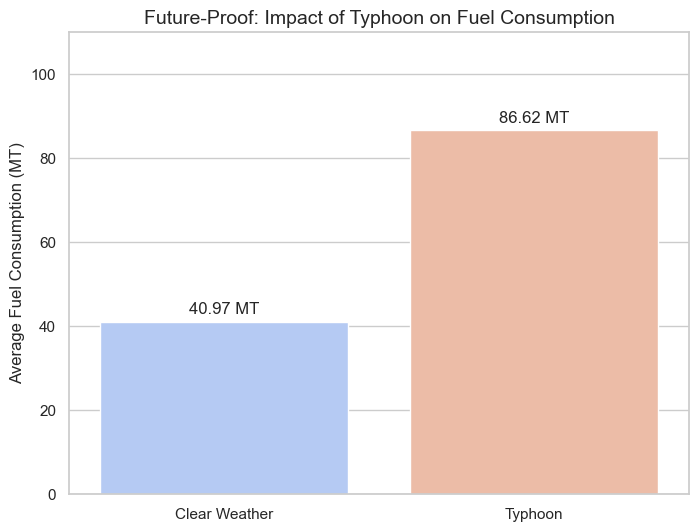

In [18]:
sns.set_theme(style="whitegrid")

categories = ['Clear Weather', 'Typhoon']
fuel_values = [40.97, 86.62]

plt.figure(figsize=(8, 6))
plot = sns.barplot(x=categories, y=fuel_values, hue=categories, palette="coolwarm", legend=False)


for p in plot.patches:
    plot.annotate(format(p.get_height(), '.2f') + " MT",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center',
                  xytext = (0, 9),
                  textcoords = 'offset points')

plt.title('Future-Proof: Impact of Typhoon on Fuel Consumption', fontsize=14)
plt.ylabel('Average Fuel Consumption (MT)')
plt.ylim(0, 110) 
plt.show()